# Extraction Notebook

In [ ]:
import os
import re
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sqlalchemy import create_engine
from sqlalchemy.engine.base import Engine

# Add project root to path to allow src imports
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))

from src.config import DB_CONNECTION_STRING

In [15]:
engine: Engine = create_engine(DB_CONNECTION_STRING)

# Query the LABELED view
query = "SELECT * FROM retail_returns.labeled_reviews_v"
df = pd.read_sql(query, engine)

print("DataFrame loaded successfully from the database.")

DataFrame loaded successfully from the database.


In [16]:
print(f"Data Shape: {df.shape}")
display(df.head())

Data Shape: (22641, 6)


,index_id,clothing_id,age,review_text,rating,return_category
0,0,767,33,Absolutely wonderful - silky and sexy and comf...,4,Other
1,1,1080,34,Love this dress! it's sooo pretty. i happene...,5,Other
2,2,1077,60,I had such high hopes for this dress and reall...,3,Defect
3,3,1049,50,"I love, love, love this jumpsuit. it's fun, fl...",5,Other
4,4,847,47,This shirt is very flattering to all due to th...,5,Other


#### Visualizing the appearance of different return categories

return_category
Sizing    11980
Style      5103
Other      3350
Defect     2208
Name: count, dtype: int64


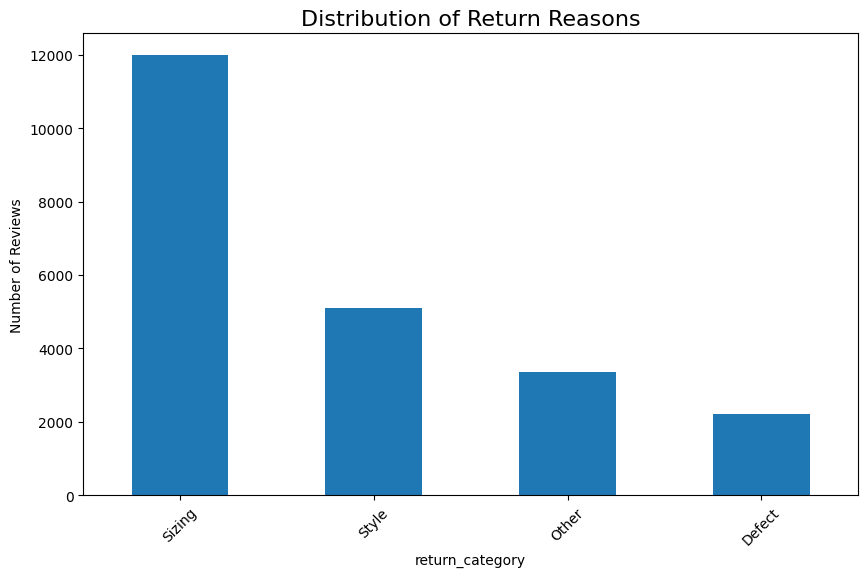

In [17]:
df["return_category"].value_counts().plot(kind="bar", figsize=(10, 6), rot=45)
plt.title("Distribution of Return Reasons", fontsize=16)
plt.ylabel("Number of Reviews")

# Printing exact values
print(df["return_category"].value_counts())
plt.show()

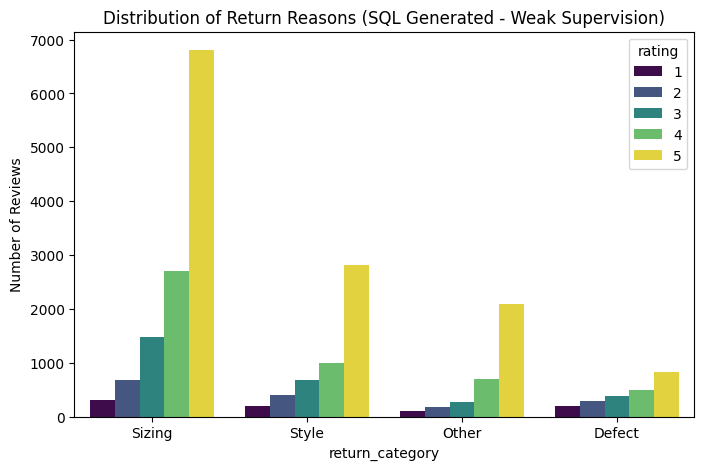

return_category
Sizing    0.529129
Style     0.225388
Other     0.147962
Defect    0.097522
Name: proportion, dtype: float64


In [18]:
plt.figure(figsize=(8, 5))
order = df["return_category"].value_counts().index
sns.countplot(
    data=df, x="return_category", order=order, hue="rating", palette="viridis"
)
plt.ylabel("Number of Reviews")
plt.title("Distribution of Return Reasons (SQL Generated - Weak Supervision)")

plt.show()

# Printing proportions of categories
print(df["return_category"].value_counts(normalize=True))

#### Saving the extracted data to a CSV file

In [19]:
output_path = "../data/interim/labeled_reviews.csv"
df.to_csv(output_path, index=False)

print(f"Data successfully saved to {output_path}")

Data successfully saved to ../data/interim/labeled_reviews.csv
